
<p>This lab on the Introduction to R comes from "Introduction to Statistical Learning with Applications in R" by Gareth James, Daniela Witten, Trevor Hastie and Robert Tibshirani. It was re-implemented in Fall 2017 in python by R. Jordan Crouser at Smith College.</p>



<h1 id="Loading-Data">Loading Data<a class="anchor-link" href="#Loading-Data">¶</a></h1>



<p>For most analyses, the first step involves importing a data set into <code>python</code>. For this class, a lot of the data comes from the <code>ISLR</code> package. Unfortunately this isn't available for <code>python</code> so I've exported the data to CSV to make things easier. We can use the <code>read_csv()</code> function from the <code>pandas</code> library to import it.</p>
<p>We begin by loading in the <code>Auto</code> data set.</p>


In [0]:

%matplotlib inline
import pandas as pd


Auto = pd.read_csv("http://www-bcf.usc.edu/~gareth/ISL/Auto.csv")




<p>Nothing happens when you run this, but now the data is available in your environment.</p>
<p>To view the data, we can either print the entire dataset by typing its name, or we can just look at the first few rows with the <code>head()</code> function.</p>


In [3]:

Auto.head()



,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino



<p>Now that we have the data, we can begin to learn things about it. For example, if we want to know how many rows and columns the DataFrame contains:</p>


In [4]:

Auto.shape



(397, 9)


<p>This tells us that the data has 392 observations, or rows, and nine variables, or columns.</p>
<p>The ${\tt .dtypes}$ atribute tells us that most of the variables are numeric or integer, although the ${\tt name }$ variable is a character vector.</p>


In [5]:

Auto.dtypes



mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
year              int64
origin            int64
name             object
dtype: object


<h1 id="Summary-statistics">Summary statistics<a class="anchor-link" href="#Summary-statistics">¶</a></h1>



<p>Often, we want to know some basic things about variables in our data. Calling the <code>describe()</code> method on a DataFrame will give you an idea of some of the distributions of your variables.</p>



<p>The ${\tt describe()}$ function produces a numerical summary of each (quantitative) variable in
a particular data set.</p>


In [6]:

Auto.describe()



,mpg,cylinders,displacement,weight,acceleration,year,origin
count,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000
mean,23.515869,5.458438,193.532746,2970.261965,15.555668,75.994962,1.574307
std,7.825804,1.701577,104.379583,847.904119,2.749995,3.690005,0.802549
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.000000,2223.000000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,146.000000,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3609.000000,17.100000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000



<p>The summary suggests that <code>origin</code> might be better thought of as a factor. It only seems to have three possible values, <code>1</code>, <code>2</code> and <code>3</code>. If we read the documentation about the data we will learn that these numbers correspond to where the car is from: 1. American, 2. European, 3. Japanese. So let's cast that variable into a categorical variable using using the  <code>astype()</code> function .</p>


In [0]:

Auto["origin"] = Auto["origin"].astype('category')




<p>If we want to include a summary of this variable when we call <code>.describe()</code>, we need to let <code>python</code> know we want ALL the variables (not just the quantitative ones):</p>


In [8]:

Auto.describe(include='all')



,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
count,397.000000,397.000000,397.000000,397,397.000000,397.000000,397.000000,397.0,397
unique,NaN,NaN,NaN,94,NaN,NaN,NaN,3.0,304
top,NaN,NaN,NaN,150,NaN,NaN,NaN,1.0,ford pinto
freq,NaN,NaN,NaN,22,NaN,NaN,NaN,248.0,6
mean,23.515869,5.458438,193.532746,NaN,2970.261965,15.555668,75.994962,NaN,NaN
std,7.825804,1.701577,104.379583,NaN,847.904119,2.749995,3.690005,NaN,NaN
min,9.000000,3.000000,68.000000,NaN,1613.000000,8.000000,70.000000,NaN,NaN
25%,17.500000,4.000000,104.000000,NaN,2223.000000,13.800000,73.000000,NaN,NaN
50%,23.000000,4.000000,146.000000,NaN,2800.000000,15.500000,76.000000,NaN,NaN
75%,29.000000,8.000000,262.000000,NaN,3609.000000,17.100000,79.000000,NaN,NaN



<p>Or, just look at one particular statistic using <code>mean()</code>, <code>std()</code>, <code>median()</code>, and more using the <code>numpy</code> library:</p>


In [9]:

import numpy as np
np.mean(Auto['displacement'])



193.53274559193954


<h1 id="Plotting">Plotting<a class="anchor-link" href="#Plotting">¶</a></h1>



<p>As in <code>R</code>, we can use the <code>ggplot</code> package to produce simple graphics. <code>ggplot</code> has a particular syntax, which looks like this</p>


    100% |████████████████████████████████| 2.2MB 9.7MB/s 


/usr/local/lib/python3.6/dist-packages/ggplot/utils.py:81: FutureWarning: pandas.tslib is deprecated and will be removed in a future version.
You can access Timestamp as pandas.Timestamp
  pd.tslib.Timestamp,
/usr/local/lib/python3.6/dist-packages/ggplot/stats/smoothers.py:4: FutureWarning: The pandas.lib module is deprecated and will be removed in a future version. These are private functions and can be accessed from pandas._libs.lib instead
  from pandas.lib import Timestamp
/usr/local/lib/python3.6/dist-packages/statsmodels/compat/pandas.py:56: FutureWarning: The pandas.core.datetools module is deprecated and will be removed in a future version. Please use the pandas.tseries module instead.
  from pandas.core import datetools


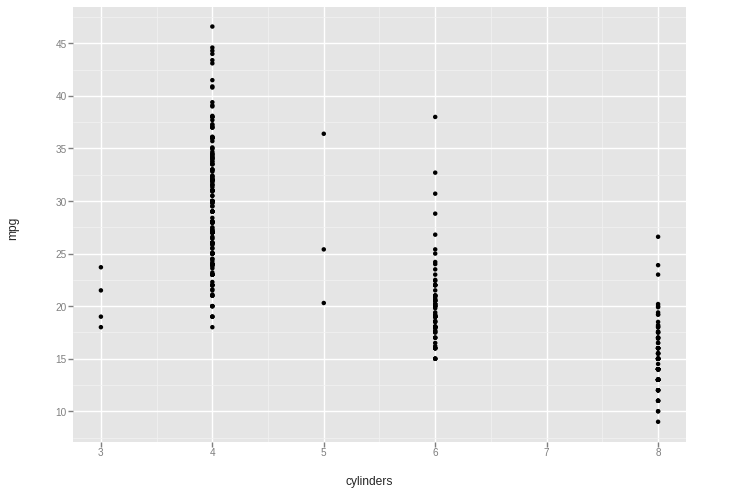

<ggplot: (-9223363273117678560)>

In [11]:
!pip install ggplot
from ggplot import *

ggplot(Auto, aes(x='cylinders', y='mpg')) + \
    geom_point()




<p>The basic idea is that you need to initialize a plot with <code>ggplot()</code> and then add "geoms" (short for geometric objects) to the plot. The <code>ggplot</code> package is based on the <a href="https://www.google.com/url?sa=t&amp;rct=j&amp;q=&amp;esrc=s&amp;source=web&amp;cd=1&amp;cad=rja&amp;uact=8&amp;ved=0ahUKEwjV6I6F4ILPAhUFPT4KHTFiBwgQFggcMAA&amp;url=https%3A%2F%2Fwww.amazon.com%2FGrammar-Graphics-Statistics-Computing%2Fdp%2F0387245448&amp;usg=AFQjCNF5D6H3ySCsgqBTdp96KNF3bGyU2Q&amp;sig2=GnNgoN6Ztn3AJSTJYaMPwA">Grammar of Graphics</a>, a famous book on data visualization theory. It is a way to map attributes in your data (like variables) to "aesthetics" on the plot. The parameter <code>aes()</code> is short for aesthetic.</p>
<p>For more about the <code>ggplot2</code> syntax, view the documentation using the <code>help()</code> function. There are also great online resources for <code>ggplot2</code>, like <a href="http://ggplot.yhathq.com/">ggplot from ŷhat</a>.</p>


In [12]:

help(ggplot)



Help on class ggplot in module ggplot.ggplot:

class ggplot(builtins.object)
 |  ggplot is the base layer or object that you use to define
 |  the components of your chart (x and y axis, shapes, colors, etc.).
 |  You can combine it with layers (or geoms) to make complex graphics
 |  with minimal effort.
 |  
 |  Parameters
 |  -----------
 |  aesthetics :  aes (ggplot.components.aes.aes)
 |      aesthetics of your plot
 |  data :  pandas DataFrame (pd.DataFrame)
 |      a DataFrame with the data you want to plot
 |  
 |  Examples
 |  ----------
 |  >>> p = ggplot(aes(x='carat', y='price'), data=diamonds)
 |  >>> print(p + geom_point())
 |  
 |  Methods defined here:
 |  
 |  __init__(self, aesthetics, data)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  __repr__(self)
 |      Return repr(self).
 |  
 |  add_labels(self)
 |  
 |  add_legend(self, legend)
 |  
 |  apply_axis_labels(self)
 |  
 |  apply_axis_scales(self)
 |  
 |  apply_coords(self)
 |  
 


<p>The <code>cylinders</code> variable is stored as a numeric vector, so <code>python</code> has treated it
as quantitative. However, since there are only a small number of possible
values for cylinders, one may prefer to treat it as a qualitative variable.
We can turn it into a factor, again using an <code>astype()</code> call.</p>


In [0]:

Auto["cylinders"] = Auto["cylinders"].astype('category')




<p>To view the relationship between a categorical and a numeric variable, we might want to produce <em>boxplots</em>. As usual, a number of options can be specified in order to customize the plots.</p>


In [0]:

ggplot(Auto, aes(x='cylinders', y='mpg')) + \
    geom_boxplot() + \
    xlab("Cylinders") + \
    ylab("MPG")




<p>The geom <code>geom_histogram()</code> can be used to plot a histogram.</p>


In [0]:

ggplot(Auto, aes(x='mpg')) + \
    geom_histogram()




<p>The function warns us that it used a default number of bins, so we should think more carefully about what value makes sense.</p>


In [0]:

ggplot(Auto, aes(x='mpg')) + \
    geom_histogram(binwidth=5) 




<p>For small datasets, we might want to see all the bivariate relationships between the variables. The <code>pandas</code> package has a <code>scatter_matrix()</code> function that can do just that. (Be patient-- it takes a long time!)</p>


In [0]:

pd.scatter_matrix(Auto, alpha=0.2, figsize=(10, 10))




<p>Sometimes, we might want to save a plot for use outside of our Jupyter notebook. To do this, we call the plot's <code>save()</code> function.</p>


In [0]:

p = ggplot(Auto, aes(x='mpg')) + \
    geom_histogram(binwidth=5)

p.save(filename = "histogram.png")

